In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [51]:
import pandas as pd

map_dire = r'4_5_2021_Magnet_Measurement.csv' #path to the .csv file

df = pd.read_csv(map_dire)

data = np.loadtxt(map_dire,skiprows=1,delimiter=',') 

data.shape

(37884, 4)

In [52]:
# --- Read CSV file (assuming numeric data, no header) ---
magnetic_field_data = np.loadtxt(map_dire, delimiter=',',skiprows=1)

step = 2  # resolution of magnetic field measurement

# Extract columns
x_data = magnetic_field_data[:, 0]
y_data = magnetic_field_data[:, 1]
z_data = magnetic_field_data[:, 2]
B_data = np.abs(magnetic_field_data[:, 3])

# Create coordinate axes
x = np.arange(0, np.max(x_data) + step, step)
y = np.arange(0, np.max(y_data) + step, step)
z = np.arange(0, np.max(z_data) + step, step)



In [53]:
# Initialize grids
Bxz = np.zeros((len(x), len(z)))
Bxy = np.zeros((len(x), len(y)))
Byz = np.zeros((len(y), len(z)))

In [54]:
# Fill grids
for i in range(len(magnetic_field_data)):
    xi = int(x_data[i] / step)
    yi = int(y_data[i] / step)
    zi = int(z_data[i] / step)

    Bxz[xi, zi] = B_data[i]
    Bxy[xi, yi] = B_data[i]
    Byz[yi, zi] = B_data[i]



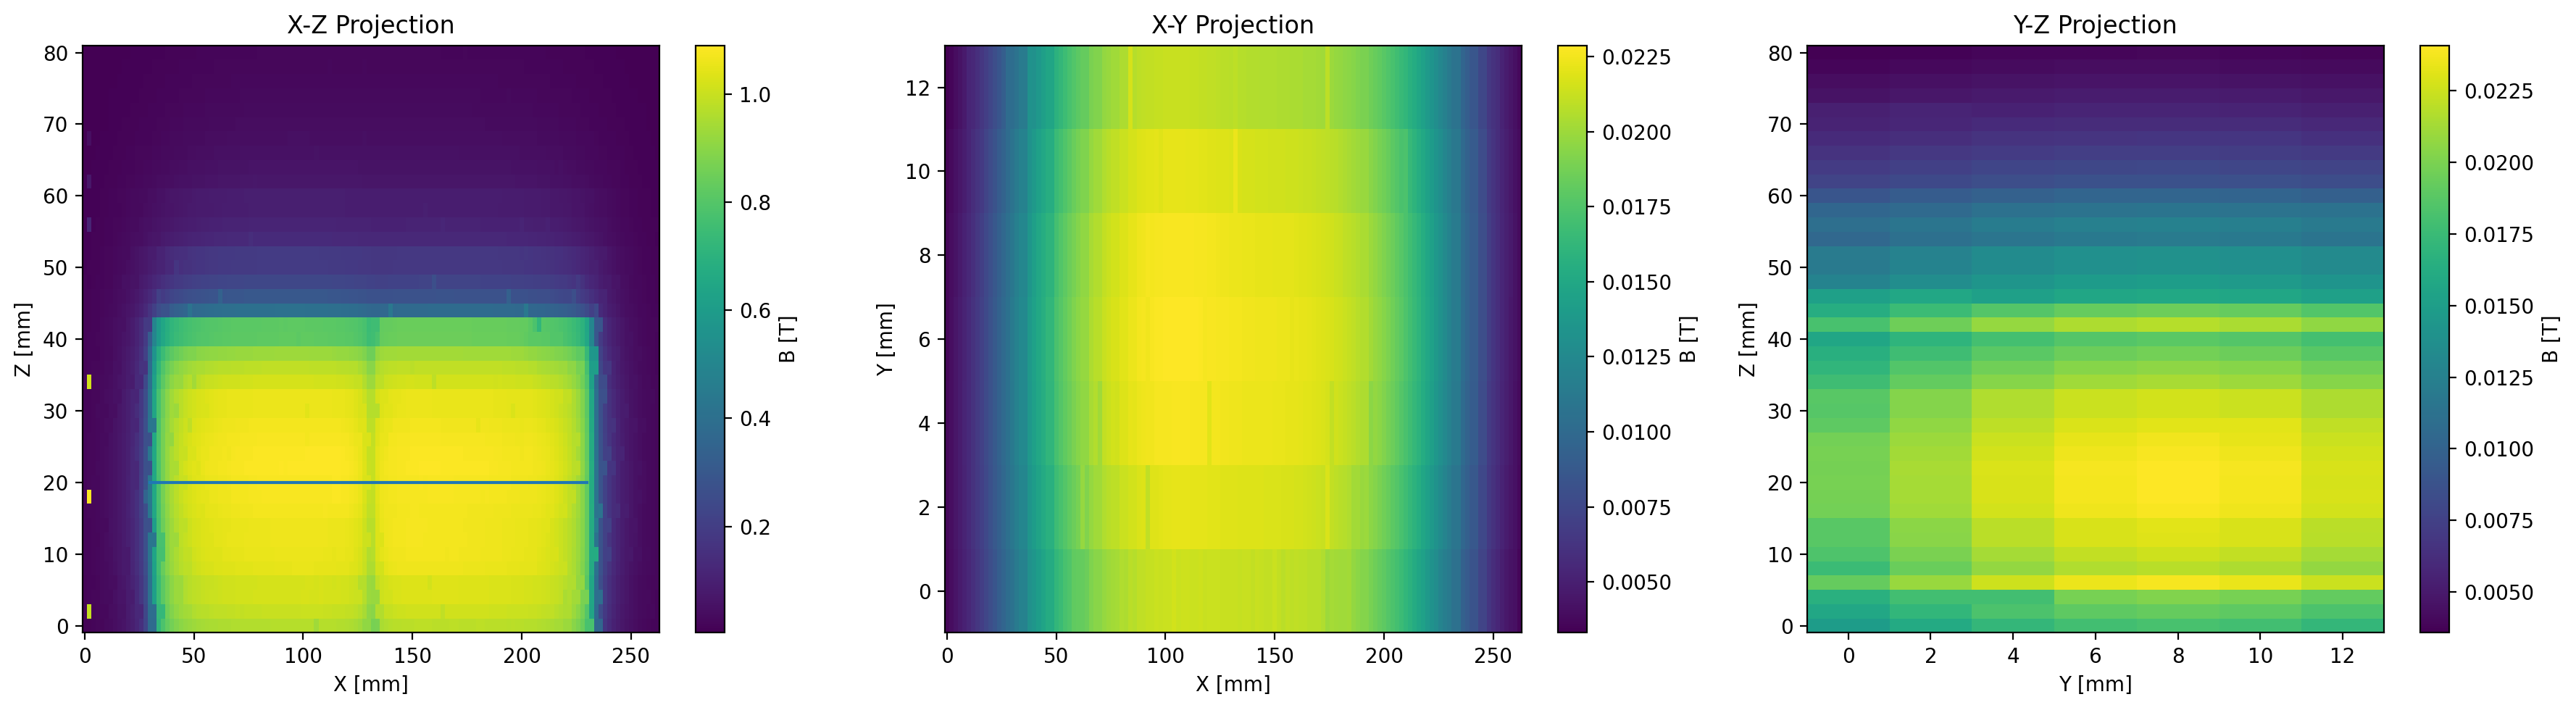

In [55]:
# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5),dpi=200)

# X-Z Projection
im0 = axs[0].pcolormesh(x, z, Bxz.T, )
axs[0].plot([30,230],[20,20],)

axs[0].set_title("X-Z Projection")
axs[0].set_xlabel("X [mm]")
axs[0].set_ylabel("Z [mm]")
fig.colorbar(im0, ax=axs[0], label="B [T]")

# X-Y Projection
im1 = axs[1].pcolormesh(x, y, Bxy.T, )
axs[1].set_title("X-Y Projection")
axs[1].set_xlabel("X [mm]")
axs[1].set_ylabel("Y [mm]")
fig.colorbar(im1, ax=axs[1], label="B [T]")

# Y-Z Projection
im2 = axs[2].pcolormesh(y, z, Byz.T,)
axs[2].set_title("Y-Z Projection")
axs[2].set_xlabel("Y [mm]")
axs[2].set_ylabel("Z [mm]")
fig.colorbar(im2, ax=axs[2], label="B [T]")

plt.tight_layout()
plt.show()

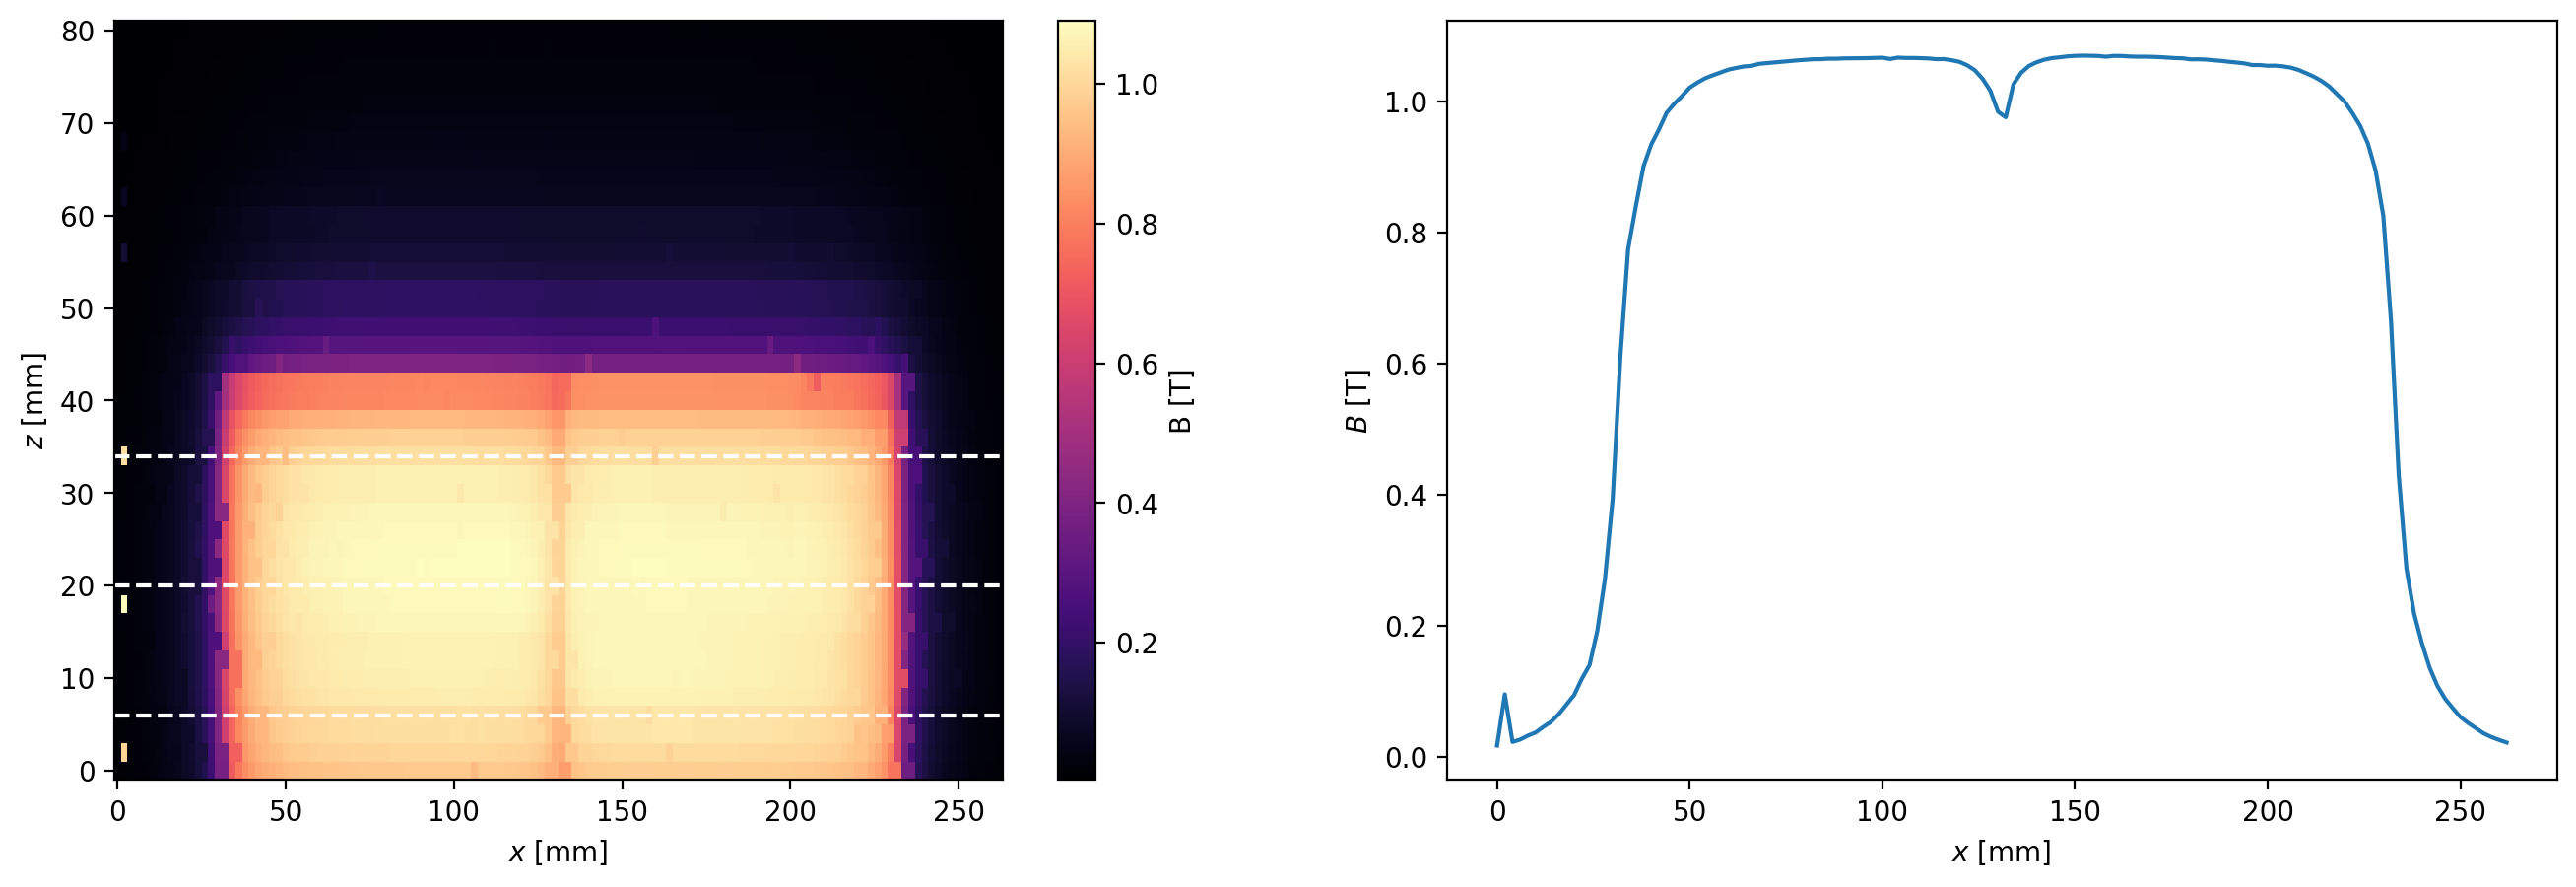

In [56]:
fig, ax = plt.subplots(1,2,figsize=(16, 5),dpi=200)
im0 = ax[0].pcolormesh(x, z, Bxz.T,cmap='magma')
fig.colorbar(im0, ax=ax[0], label="B [T]")
ax[0].axhline(z[10], color='white', linestyle='--', label='Y=20mm')
ax[0].axhline(z[17], color='white', linestyle='--', label='Y=40mm')
ax[0].axhline(z[3], color='white', linestyle='--', label='Y=7mm')

ax[0].set_xlabel(r"$x$ [mm]")
ax[0].set_ylabel(r"$z$ [mm]")

ax[1].plot(x, np.mean(Bxz[:,3:17], axis=1), )

ax[1].set_xlabel(r"$x$ [mm]")
ax[1].set_ylabel(r"$B$ [T]")

Bxz_mean = np.mean(Bxz[:,3:17], axis=1)



In [57]:
#super-gaussian fits

def sg_prof(x,a,x0,fwhm,c):
    
    sg = a*(np.exp(-((x-x0)/fwhm)**(2*8)) )+c
    
    return sg

def sg_prof_no_c(x,a,x0,fwhm,):
    
    sg = a*(np.exp(-((x-x0)/fwhm)**(2*13)) )
    
    return sg



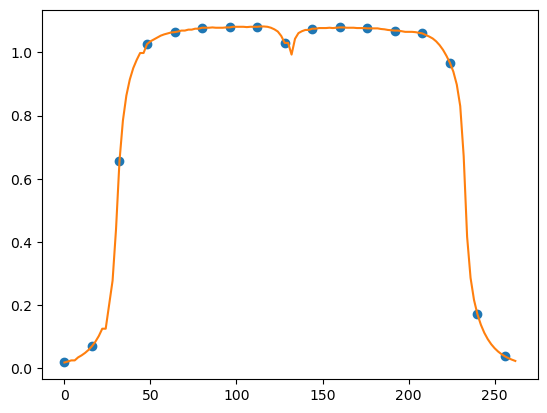

In [58]:
len(Bxz[:,10])
#extract every 8th value to give fit more freedom



Bz = np.sum(Bxz, axis=1)
x4 = x[::8]
b4 = Bxz[::8,10]
plt.plot(x4,b4,'o')
plt.plot(x, Bxz[:,10], label="Data", )

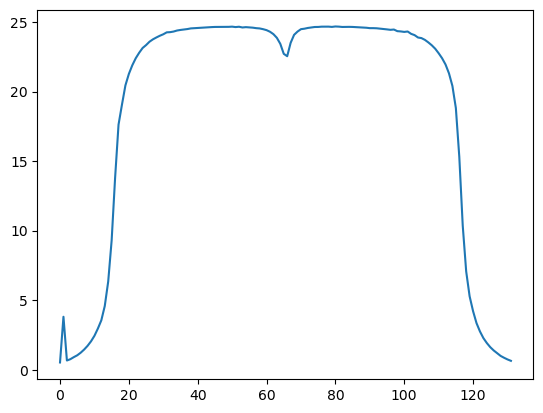

In [59]:
plt.plot(Bz)

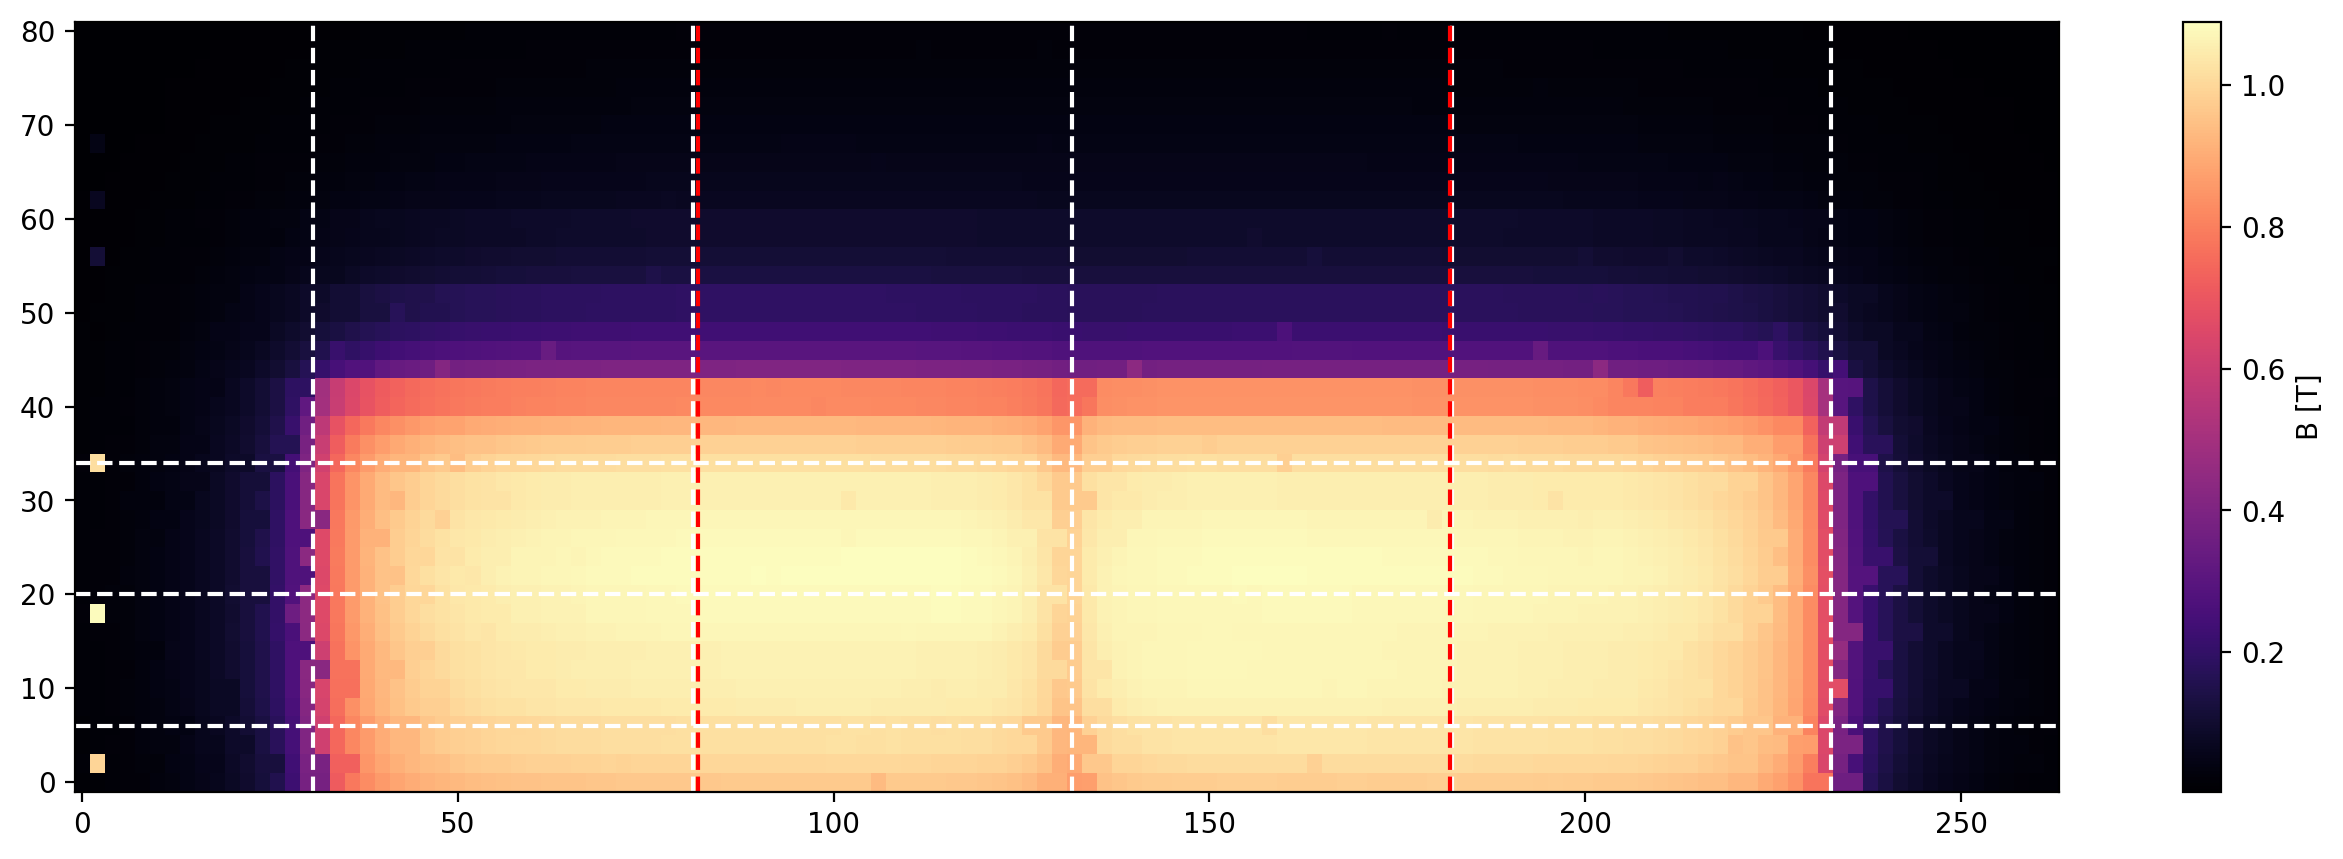

In [60]:
#finding indxes to cut -- yes, it could have been automated

fig, ax = plt.subplots(figsize=(16, 5),dpi=200)
im0 = ax.pcolormesh(x, z, Bxz.T,cmap='magma')
fig.colorbar(im0, ax=ax, label="B [T]")
ax.axvline(x0-101, color='white', linestyle='--',)
ax.axvline(x0, color='white', linestyle='--',)
ax.axvline(x0+101, color='white', linestyle='--',)

i1=41
i2=91

ax.axvline(x0-101/2, color='white', linestyle='--',)
ax.axvline(x[i1], color='r', linestyle='--',)
ax.axvline(x0+101/2, color='white', linestyle='--',)
ax.axvline(x[i2], color='r', linestyle='--',)
x0+101 -x[i1] -(x0 -101 -x[i2])

ax.axhline(20, color='white', linestyle='--', label='Y=20mm')
ax.axhline(34, color='white', linestyle='--', label='Y=40mm')
ax.axhline(6, color='white', linestyle='--', label='Y=7mm')



(91, 41) (91, 41) (132, 41)
(182, 41)


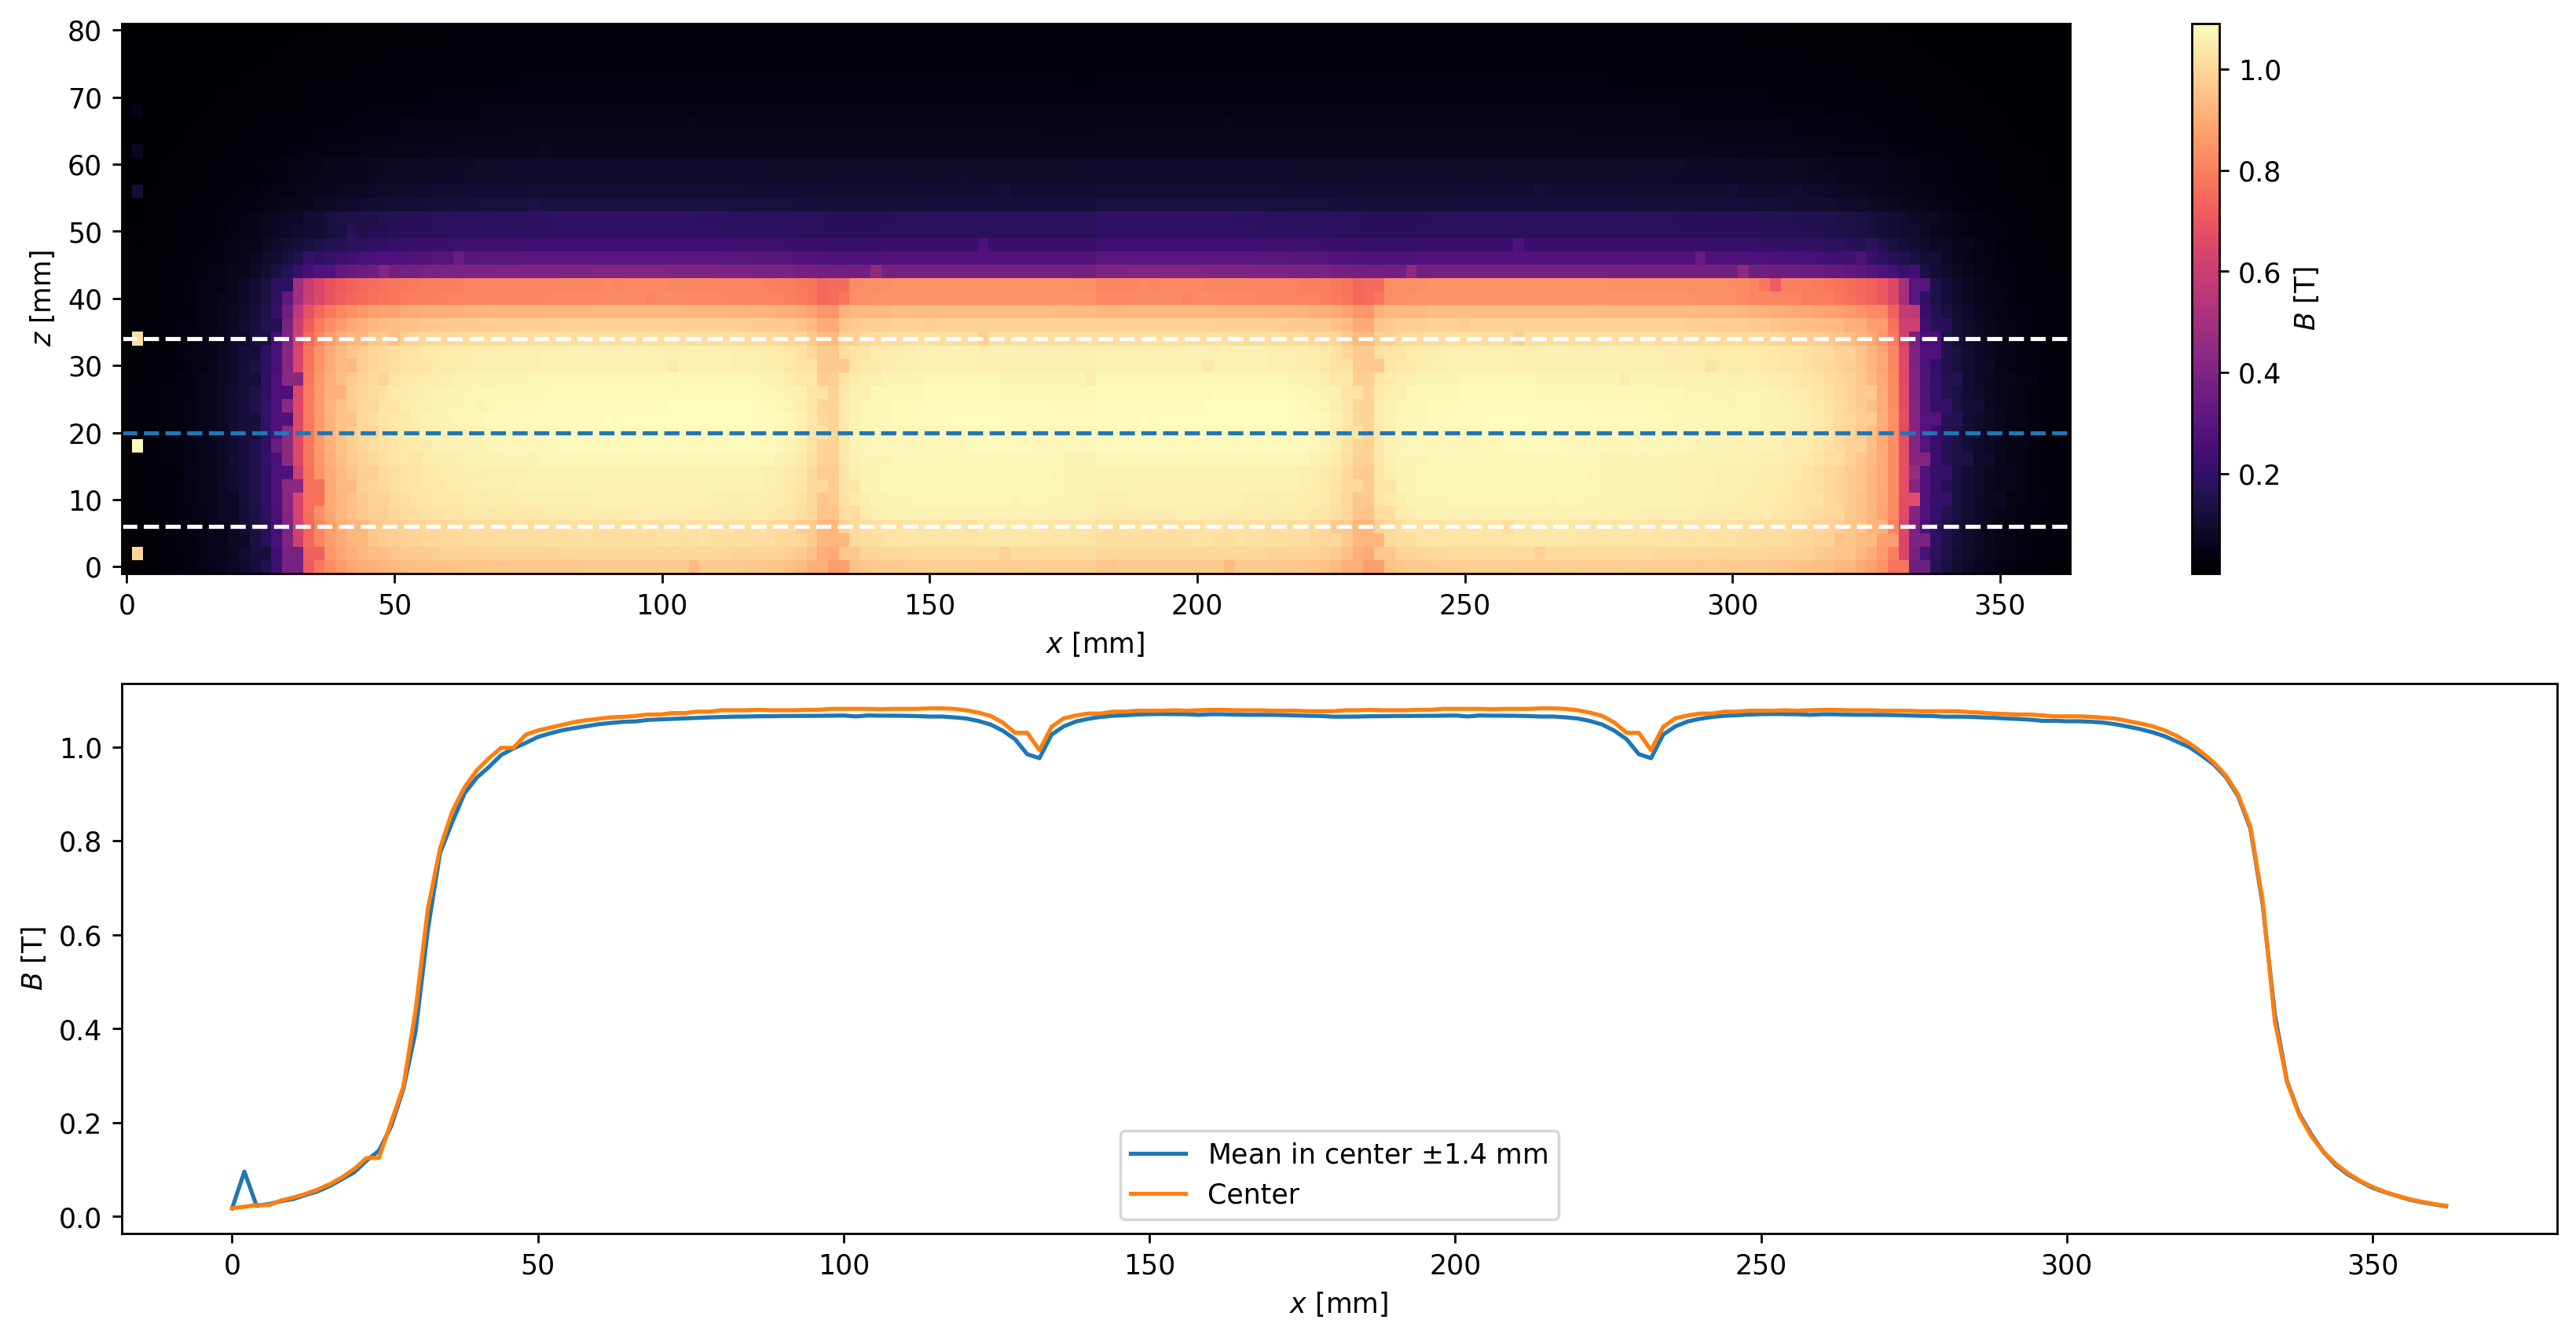

In [61]:
Bxz1 = Bxz[:i2,]
Bxz2 = Bxz[i1:,]

print(Bxz1.shape,Bxz2.shape,Bxz.shape)


#concatenate the two parts 
Bxz_long = np.concatenate((Bxz1,Bxz2), axis=0)

#new x axis
x_long =np.zeros(Bxz_long.shape[0])
dx = x[1] - x[0]

for i in range(Bxz_long.shape[0]):
    x_long[i] = x[0] + i*dx


print(Bxz_long.shape)

fig, ax = plt.subplots(2, 1, figsize=(16, 8), dpi=250)
im0 = ax[0].pcolormesh(x_long, z, Bxz_long.T,cmap='magma')
ax[0].axhline(20, color='C0', linestyle='--', label='Y=20mm')
fig.colorbar(im0, ax=ax[0], label=r"$B$ [T]")

Bz_mean_long = np.mean(Bxz_long[:,3:17], axis=1)
ax[1].plot(x_long, Bz_mean_long, label=r"Mean in center $\pm 1.4$ mm"  )

#ax[0].axhline(20, color='white', linestyle='--', label='Y=20mm')
ax[0].axhline(34, color='white', linestyle='--', label='Y=34mm')
ax[0].axhline(6, color='white', linestyle='--', label='Y=6mm')

ax[0].set_xlabel(r"$x$ [mm]")
ax[0].set_ylabel(r"$z$ [mm]")
ax[1].plot(x_long, Bxz_long[:,10], label="Center")
ax[1].set_xlabel(r"$x$ [mm]")
ax[1].set_ylabel(r"$B$ [T]")

ax[1].legend()

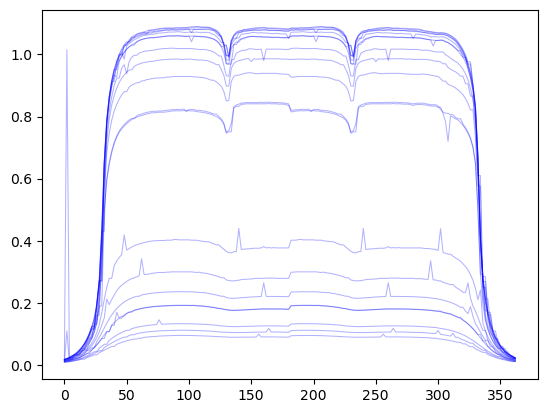

In [62]:
plt.plot(x_long, Bxz_long[:,10:30], c='b',alpha=0.3,lw=0.75,)


#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-
a     = 1.059373835155139 $\pm$ 0.002599025558002207  (  0.2453360156494327  %)
x0    = 182.3720058872899 $\pm$ 0.1408556838365249  (  0.07723536468835955  %)
fwhm  = 153.5951529520899 $\pm$ 0.14503983155335204  (  0.09442995352763087  %)
#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-



Text(0, 0.5, '$B$ [T]')

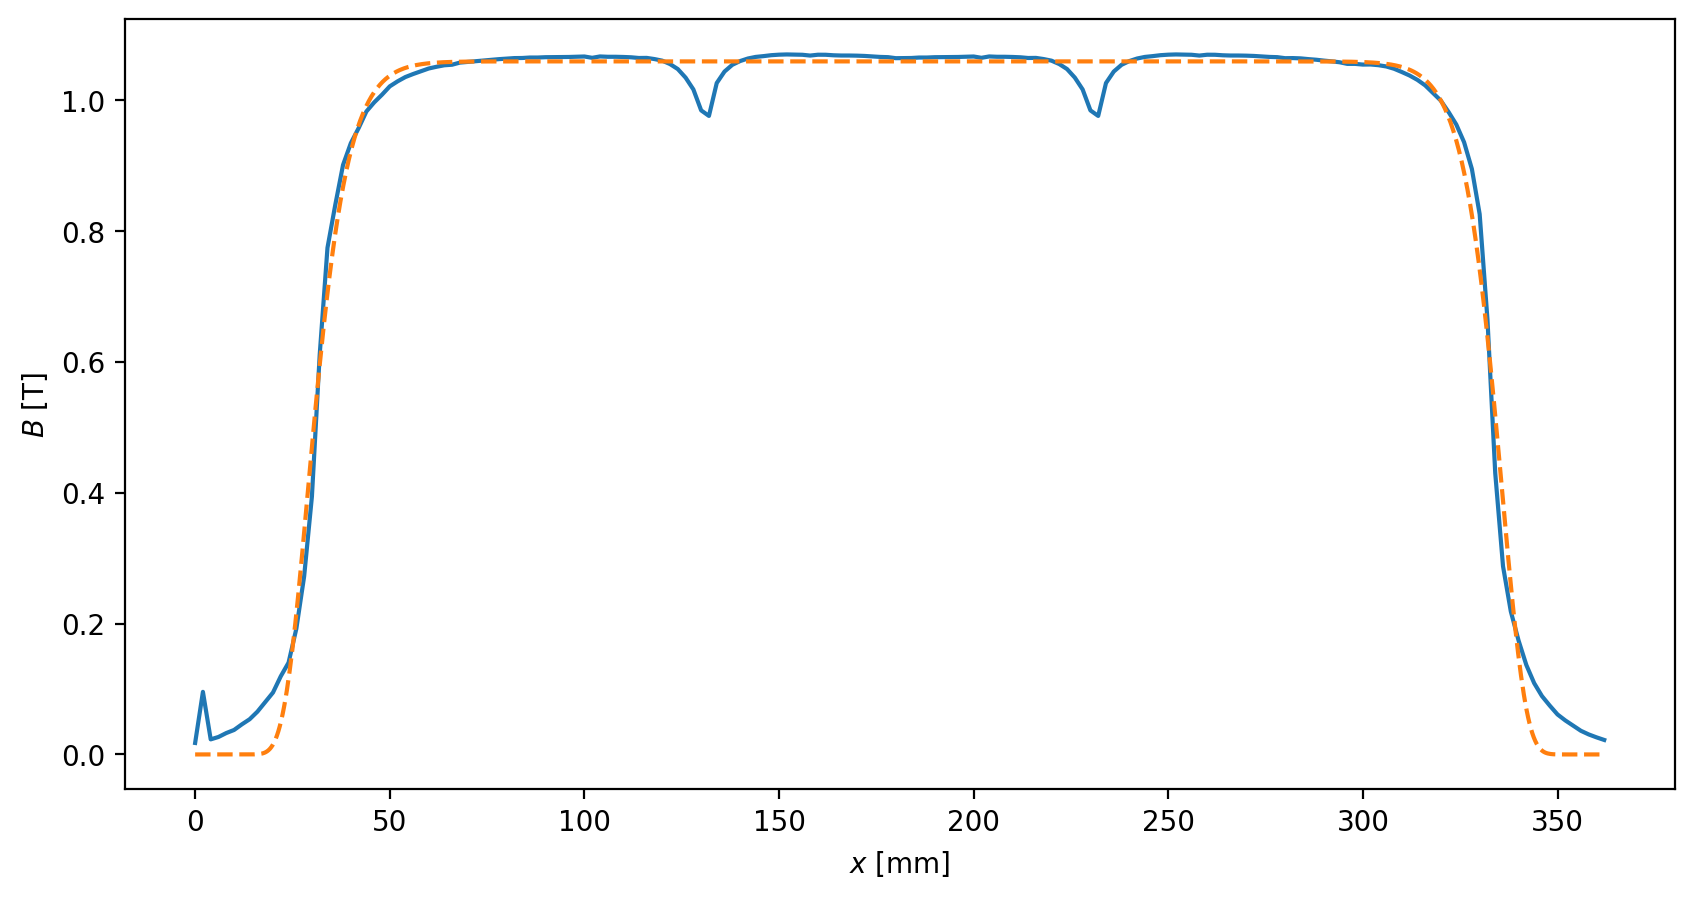

In [63]:
fig, ax = plt.subplots(figsize=(10, 5),dpi=200)
ax.plot(x_long, Bz_mean_long, label="X-Z at Y=20mm")

popt, pcov = curve_fit(sg_prof_no_c,     # functiion
                    x_long,               # x values
                    Bz_mean_long ,        # y values   
                    p0=[1.03511768e+00, 184, 1.53948856e+02], # initital guess for the parameters
                    maxfev=30000,
                    sigma  = np.ones_like(Bz_mean_long) * 0.01
                    )
print()
print('#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-' )
#print('#-#-#-#-#-#-#-#-#-# Fit pro d =',,' -#-#-#-#-#-#-#-#-' )

print("a     =", popt[0], r'$\pm$', pcov[0,0]**0.5,' ( ',pcov[0,0]**0.5 /popt[0]*100,' %)') 
print("x0    =", popt[1], r'$\pm$', pcov[1,1]**0.5,' ( ',pcov[1,1]**0.5 /popt[1]*100,' %)') 
print("fwhm  =", popt[2], r'$\pm$', pcov[2,2]**0.5,' ( ',pcov[2,2]**0.5 /popt[2]*100,' %)')
#print("c     =", popt[3], r'$\pm$', pcov[3,3]**0.5,' ( ',pcov[3,3]**0.5 /popt[3]*100,' %)')
#print("m     =", popt[4], r'$\pm$', pcov[4,4]**0.5,' ( ',pcov[4,4]**0.5 /popt[4]*100,' %)')
print('#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-' )
print()


x_l = np.linspace(x_long[0], x_long[-1],   1000)

sg_ = sg_prof_no_c(x_l,*popt)

ax.plot(x_l, sg_, label="SG Fit", linestyle='--')

ax.set_xlabel(r"$x$ [mm]")
ax.set_ylabel(r"$B$ [T]")
